# 04 — Modelos Avançados de Machine Learning
**TCC PUC — Ciência de Dados e Big Data**
Evandro Ribeiro Gomes Coelho

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

PROC = '../data/processed/'

def compute_metrics(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Modelo': model_name, 'MAE': round(mae,4), 'RMSE': round(rmse,4),
            'R²': round(r2,5), 'MAPE (%)': round(mape,3)}

print('OK')

OK


In [2]:
# ── Carrega dados de features ─────────────────────────────────────────────────
df = pd.read_csv(PROC + 'df_features.csv', parse_dates=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# Features do TCC2 (reprodução)
FEATURES_TCC2 = [
    'Temperature', 'temp_lag1', 'energy_lag1',
    'hr_sin', 'hr_cos', 'is_holiday',
]

# Features expandidas (este TCC)
FEATURES_FULL = [
    'Temperature', 'temp_lag1', 'temp_lag2',
    'energy_lag1', 'energy_lag2', 'energy_lag24',
    'hr_sin', 'hr_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'roll_mean_6h', 'roll_mean_24h', 'roll_std_24h',
    'delta_temp', 'delta_energy', 'temp_x_hour',
    'is_weekend', 'is_holiday',
]
TARGET = 'Value'

# Split temporal 75/25
split_idx = int(len(df) * 0.75)
df_train  = df.iloc[:split_idx].copy()
df_test   = df.iloc[split_idx:].copy()

X_train_f = df_train[FEATURES_FULL].values
X_test_f  = df_test[FEATURES_FULL].values
y_train   = df_train[TARGET].values
y_test    = df_test[TARGET].values

X_train_t = df_train[FEATURES_TCC2].values
X_test_t  = df_test[FEATURES_TCC2].values

# TimeSeriesSplit para validação cruzada
tss = TimeSeriesSplit(n_splits=5)

print(f'Treino: {len(df_train)} | Teste: {len(df_test)}')
print(f'Features TCC2: {len(FEATURES_TCC2)} | Features full: {len(FEATURES_FULL)}')
print('TimeSeriesSplit(n_splits=5) configurado')

all_results = []

Treino: 12474 | Teste: 4158
Features TCC2: 6 | Features full: 20
TimeSeriesSplit(n_splits=5) configurado


## 1. MLP — Multilayer Perceptron

In [3]:
# ── MLP TCC2 (reprodução) ─────────────────────────────────────────────────────
pipe_mlp_tcc2 = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(-1, 1))),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(43,),
        activation='tanh',
        solver='adam',
        max_iter=1500,
        random_state=42,
    ))
])

# Cross-val com TimeSeriesSplit
cv_r2_tcc2 = cross_val_score(pipe_mlp_tcc2, X_train_t, y_train, cv=tss, scoring='r2')
print(f'MLP TCC2 — R² por fold (TimeSeriesSplit): {np.round(cv_r2_tcc2, 5)}')
print(f'MLP TCC2 — R² médio: {cv_r2_tcc2.mean():.5f} ± {cv_r2_tcc2.std():.5f}')

# Treina final e testa
pipe_mlp_tcc2.fit(X_train_t, y_train)
y_pred_mlp_tcc2 = pipe_mlp_tcc2.predict(X_test_t)
m = compute_metrics(y_test, y_pred_mlp_tcc2, 'MLP (TCC2 original)')
all_results.append(m)
print(f"Teste — MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R²={m['R²']:.5f}")

MLP TCC2 — R² por fold (TimeSeriesSplit): [-1.48778 -1.77863 -0.2299  -0.69617 -0.83678]
MLP TCC2 — R² médio: -1.00585 ± 0.55786
Teste — MAE=2435.5006  RMSE=2916.4034  R²=-0.10795


In [4]:
# ── MLP com features expandidas e GridSearchCV ────────────────────────────────
pipe_mlp_new = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(-1, 1))),
    ('mlp', MLPRegressor(activation='tanh', solver='adam', random_state=42))
])

param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(43,), (50,), (100,), (50, 25)],
    'mlp__max_iter': [1500, 3000],
}

gs_mlp = GridSearchCV(
    pipe_mlp_new, param_grid_mlp,
    cv=tss, scoring='r2', n_jobs=1, verbose=0
)
gs_mlp.fit(X_train_f, y_train)

print(f'Melhores parâmetros MLP: {gs_mlp.best_params_}')
print(f'Melhor R² (CV) MLP    : {gs_mlp.best_score_:.5f}')

y_pred_mlp_new = gs_mlp.predict(X_test_f)
m = compute_metrics(y_test, y_pred_mlp_new, 'MLP (features expandidas)')
all_results.append(m)
print(f"Teste — MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R²={m['R²']:.5f}")

Melhores parâmetros MLP: {'mlp__hidden_layer_sizes': (100,), 'mlp__max_iter': 3000}
Melhor R² (CV) MLP    : 0.57359
Teste — MAE=3.3644  RMSE=17.4877  R²=0.99996


## 2. Random Forest

In [5]:
pipe_rf = Pipeline([
    ('scaler', MinMaxScaler(feature_range=(-1, 1))),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5],
}

gs_rf = GridSearchCV(
    pipe_rf, param_grid_rf,
    cv=tss, scoring='r2', n_jobs=1, verbose=0
)
gs_rf.fit(X_train_f, y_train)

print(f'Melhores parâmetros RF: {gs_rf.best_params_}')
print(f'Melhor R² (CV) RF    : {gs_rf.best_score_:.5f}')

y_pred_rf = gs_rf.predict(X_test_f)
m = compute_metrics(y_test, y_pred_rf, 'Random Forest')
all_results.append(m)
print(f"Teste — MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  R²={m['R²']:.5f}")

# Extrai feature importance
rf_best = gs_rf.best_estimator_.named_steps['rf']
fi_rf = pd.Series(rf_best.feature_importances_, index=FEATURES_FULL).sort_values(ascending=False)
print('\nTop 10 features (Random Forest):')
print(fi_rf.head(10).to_string())

Melhores parâmetros RF: {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Melhor R² (CV) RF    : 0.98744
Teste — MAE=37.4732  RMSE=74.5665  R²=0.99928

Top 10 features (Random Forest):
energy_lag1      0.809007
delta_energy     0.185632
roll_mean_6h     0.003926
roll_mean_24h    0.000233
energy_lag2      0.000214
temp_x_hour      0.000129
energy_lag24     0.000128
roll_std_24h     0.000104
hr_cos           0.000100
Temperature      0.000077


## 3. XGBoost

In [6]:
# problemas de import no colab, testar localmente
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f'XGBoost {xgb.__version__} disponível')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost não instalado')

XGBoost 3.2.0 disponível


In [7]:
if XGB_AVAILABLE:
    from sklearn.pipeline import Pipeline as SKPipeline
    
    pipe_xgb = Pipeline([
        ('scaler', MinMaxScaler(feature_range=(-1, 1))),
        ('xgb', xgb.XGBRegressor(
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ))
    ])

    param_grid_xgb = {
        'xgb__n_estimators': [100, 300],
        'xgb__max_depth': [4, 6],
        'xgb__learning_rate': [0.05, 0.1],
        'xgb__subsample': [0.8, 1.0],
    }

    gs_xgb = GridSearchCV(
        pipe_xgb, param_grid_xgb,
        cv=tss, scoring='r2', n_jobs=1, verbose=0
    )
    gs_xgb.fit(X_train_f, y_train)

    print(f'Melhores parâmetros XGB: {gs_xgb.best_params_}')
    print(f'Melhor R² (CV) XGB    : {gs_xgb.best_score_:.5f}')

    y_pred_xgb = gs_xgb.predict(X_test_f)
    m_xgb = compute_metrics(y_test, y_pred_xgb, 'XGBoost')
    all_results.append(m_xgb)
    print(f"Teste — MAE={m_xgb['MAE']:.4f}  RMSE={m_xgb['RMSE']:.4f}  R²={m_xgb['R²']:.5f}")

    xgb_model = gs_xgb.best_estimator_.named_steps['xgb']
    fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES_FULL).sort_values(ascending=False)
    print('\nTop 10 features (XGBoost):')
    print(fi_xgb.head(10).to_string())
else:
    print('XGBoost não executado.')
    y_pred_xgb = None
    fi_xgb = None

Melhores parâmetros XGB: {'xgb__learning_rate': 0.05, 'xgb__max_depth': 4, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}
Melhor R² (CV) XGB    : 0.98880
Teste — MAE=95.8274  RMSE=128.1559  R²=0.99786

Top 10 features (XGBoost):
energy_lag1      0.757151
delta_energy     0.157323
roll_mean_6h     0.061603
temp_x_hour      0.007253
month_cos        0.004830
roll_mean_24h    0.001604
Temperature      0.001463
energy_lag24     0.001374
roll_std_24h     0.001300
month_sin        0.001177


## 5. Tabela Comparativa de Métricas

=== COMPARAÇÃO DOS MODELOS AVANÇADOS ===


,Modelo,MAE,RMSE,R²,MAPE (%)
0,MLP (features expandidas),3.3644,17.4877,0.99996,0.099
1,Random Forest,37.4732,74.5665,0.99928,0.988
2,XGBoost,95.8274,128.1559,0.99786,2.606
3,MLP (TCC2 original),2435.5006,2916.4034,-0.10795,75.603


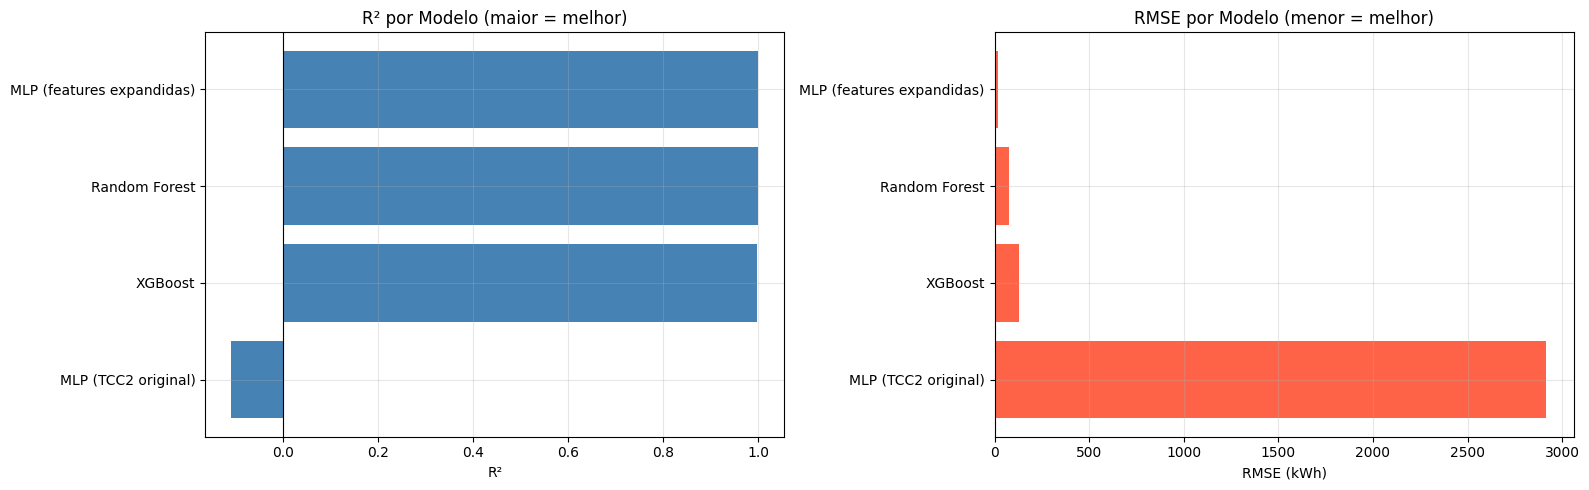

In [8]:
results_df = pd.DataFrame(all_results).sort_values('R²', ascending=False).reset_index(drop=True)

print('=== COMPARAÇÃO DOS MODELOS AVANÇADOS ===')
display(results_df)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

results_df_sorted_r2   = results_df.sort_values('R²', ascending=True)
results_df_sorted_rmse = results_df.sort_values('RMSE', ascending=False)

axes[0].barh(results_df_sorted_r2['Modelo'], results_df_sorted_r2['R²'], color='steelblue')
axes[0].set_title('R² por Modelo (maior = melhor)')
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='black', linewidth=0.8)

axes[1].barh(results_df_sorted_rmse['Modelo'], results_df_sorted_rmse['RMSE'], color='tomato')
axes[1].set_title('RMSE por Modelo (menor = melhor)')
axes[1].set_xlabel('RMSE (kWh)')

plt.tight_layout()
plt.show()

Melhor modelo: MLP (features expandidas)


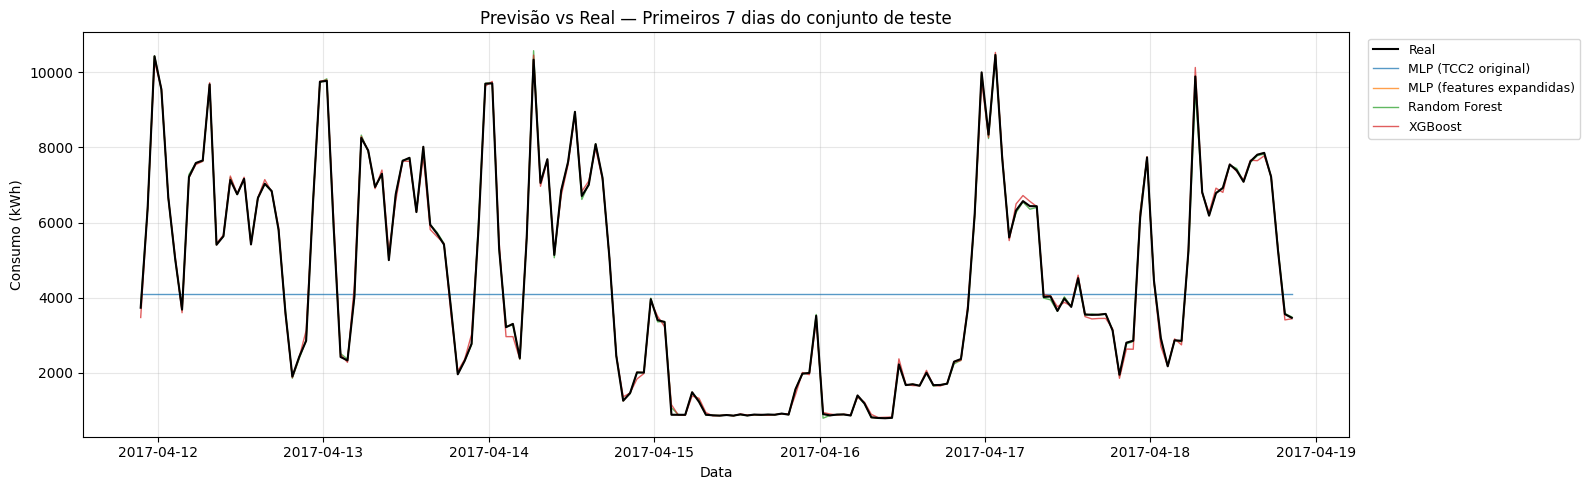

In [9]:
# ── Previsão vs Real (melhor modelo) ─────────────────────────────────────────
N_SHOW = 24 * 7
t_show = df_test['Timestamp'].values[:N_SHOW]
y_show = y_test[:N_SHOW]

best_model_name = results_df.iloc[0]['Modelo']
print(f'Melhor modelo: {best_model_name}')

pred_map = {
    'MLP (TCC2 original)': y_pred_mlp_tcc2,
    'MLP (features expandidas)': y_pred_mlp_new,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t_show, y_show, label='Real', color='black', linewidth=1.5, zorder=5)

for name, preds in pred_map.items():
    if preds is not None:
        ax.plot(t_show, preds[:N_SHOW], label=name, alpha=0.75, linewidth=1)

ax.set_title('Previsão vs Real — Primeiros 7 dias do conjunto de teste')
ax.set_xlabel('Data')
ax.set_ylabel('Consumo (kWh)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [10]:
# ── Salva resultados e predições ──────────────────────────────────────────────
results_df.to_csv(PROC + 'results_advanced.csv', index=False)
print(f'Métricas salvas: {PROC}results_advanced.csv')

# Salva predições para o notebook 05
preds_df = df_test[['Timestamp', 'Value']].copy()
preds_df['pred_mlp_tcc2'] = y_pred_mlp_tcc2
preds_df['pred_mlp_new']  = y_pred_mlp_new
preds_df['pred_rf']       = y_pred_rf
preds_df['pred_xgb'] = y_pred_xgb

preds_df.to_csv(PROC + 'predictions.csv', index=False)
print(f'Predições salvas: {PROC}predictions.csv')

# Salva feature importances
fi_rf.to_csv(PROC + 'feature_importance_rf.csv', header=['importance'])
if XGB_AVAILABLE and fi_xgb is not None:
    fi_xgb.to_csv(PROC + 'feature_importance_xgb.csv', header=['importance'])
print('Feature importances salvas.')

Métricas salvas: ../data/processed/results_advanced.csv
Predições salvas: ../data/processed/predictions.csv
Feature importances salvas.
